<a href="https://colab.research.google.com/github/Kishoby/Conceptual-Research_Hybrid-Approach/blob/Temperature_Celsius/XAI_Temperature_Statistical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load your datasets
train_df = pd.read_csv("/content/drive/MyDrive/Research v2/Research 18.03.2026/Temperature_Celsius/temp_training_dataset.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Research v2/Research 18.03.2026/Temperature_Celsius/temp_testing_dataset.csv")

target = "temperature_celsius"

# ⚠️ If you have datetime column (recommended)
# If your column name is "last_updated", use this:
# train_df["last_updated"] = pd.to_datetime(train_df["last_updated"])
# test_df["last_updated"] = pd.to_datetime(test_df["last_updated"])

# train_df.set_index("last_updated", inplace=True)
# test_df.set_index("last_updated", inplace=True)

# Evaluation function
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    y_true_safe = np.where(np.array(y_true) == 0, 1e-10, y_true)
    acc = 100 - (np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100)

    return mse, rmse, mae, r2, acc

In [2]:

var_features = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_PM10"
]

train_var = train_df[var_features].dropna()
test_var = test_df[var_features].dropna()

model = VAR(train_var)
model_fit = model.fit(maxlags=5)

lag_order = model_fit.k_ar

forecast = model_fit.forecast(
    train_var.values[-lag_order:],
    steps=len(test_var)
)

forecast_df = pd.DataFrame(
    forecast,
    index=test_var.index,
    columns=var_features
)

metrics_var = evaluate(
    test_var["temperature_celsius"],
    forecast_df["temperature_celsius"]
)

print("VAR Results")
print(metrics_var)

VAR Results
(164.0070448172982, np.float64(12.806523525816763), 9.415950263923214, -0.32053268343609664, np.float64(-49690346361.17258))


In [3]:

results = pd.DataFrame([


    {
        "Model": "VAR",
        "MSE": metrics_var[0],
        "RMSE": metrics_var[1],
        "MAE": metrics_var[2],
        "R2": metrics_var[3],
        "Accuracy (%)": metrics_var[4]
    }
]).round(4)

print(results)

  Model      MSE     RMSE    MAE      R2  Accuracy (%)
0   VAR  164.007  12.8065  9.416 -0.3205 -4.969035e+10


In [4]:
import pandas as pd

stat_results_table = pd.DataFrame([

    {
        "Model": "VAR",
        "MSE": metrics_var[0],
        "RMSE": metrics_var[1],
        "MAE": metrics_var[2],
        "R2": metrics_var[3],
        "Accuracy (%)": metrics_var[4]
    }
]).round(4)

print(stat_results_table)


  Model      MSE     RMSE    MAE      R2  Accuracy (%)
0   VAR  164.007  12.8065  9.416 -0.3205 -4.969035e+10


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 08, Jul, 2026
Time:                     05:45:18
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    37.6748
Nobs:                     103997.    HQIC:                   37.6628
Log likelihood:      -2.84335e+06    FPE:                2.26214e+16
AIC:                      37.6577    Det(Omega_mle):     2.25810e+16
--------------------------------------------------------------------
Results for equation temperature_celsius
                                     coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------------------
const                                  79.496472         4.941603           16.087           0.000
L1.temperature_celsius                  0.133021         0.003503        

,Model,Target,MSE,RMSE,MAE,R2,Accuracy (%)
0,VAR,temperature_celsius,164.007045,12.806524,9.41595,-0.320533,-4.969035e+10


,temperature_celsius,humidity,pressure_mb,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_PM10
const,79.496472,72.208203,723.738050,-10.780083,145.101321,312.465774
L1.temperature_celsius,0.133021,0.047553,-0.065090,-0.005397,-0.090577,-0.322084
L1.humidity,-0.001309,0.167958,-0.011440,-0.037426,-0.025343,-0.122010
L1.pressure_mb,-0.014904,-0.007628,0.062188,0.005136,-0.030889,-0.059926
L1.air_quality_Ozone,0.000340,-0.029120,-0.001150,0.158698,-0.012067,0.050747
L1.air_quality_Nitrogen_dioxide,-0.001449,-0.009555,-0.002105,0.023210,0.070066,0.032183
L1.air_quality_PM10,-0.000789,0.002824,0.000942,-0.002413,0.001111,0.027265
L2.temperature_celsius,0.115522,0.037505,-0.051170,-0.032332,-0.036754,-0.242113
L2.humidity,-0.003412,0.139505,-0.005680,-0.031467,-0.013235,-0.116512
L2.pressure_mb,-0.015847,-0.004401,0.060621,0.016147,-0.020227,0.016751


,Variable,Coefficient,Absolute_Coefficient
0,const,79.496472,79.496472
1,L1.temperature_celsius,0.133021,0.133021
2,L2.temperature_celsius,0.115522,0.115522
3,L4.temperature_celsius,0.100517,0.100517
4,L5.temperature_celsius,0.097808,0.097808
5,L3.temperature_celsius,0.097765,0.097765
6,L2.pressure_mb,-0.015847,0.015847
7,L1.pressure_mb,-0.014904,0.014904
8,L5.pressure_mb,-0.013827,0.013827
9,L4.pressure_mb,-0.011444,0.011444


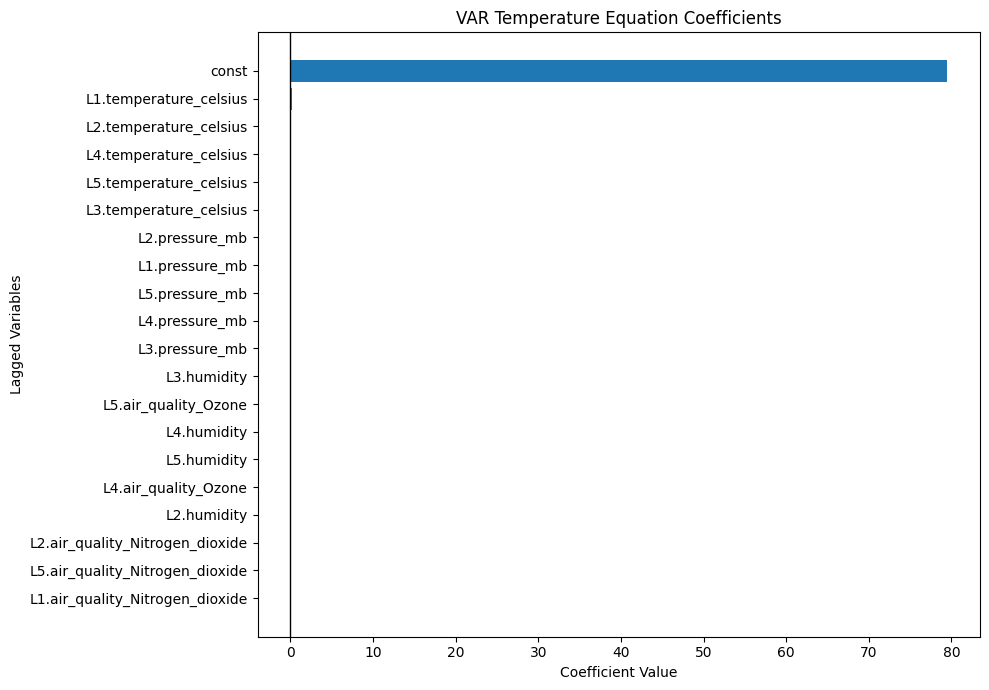

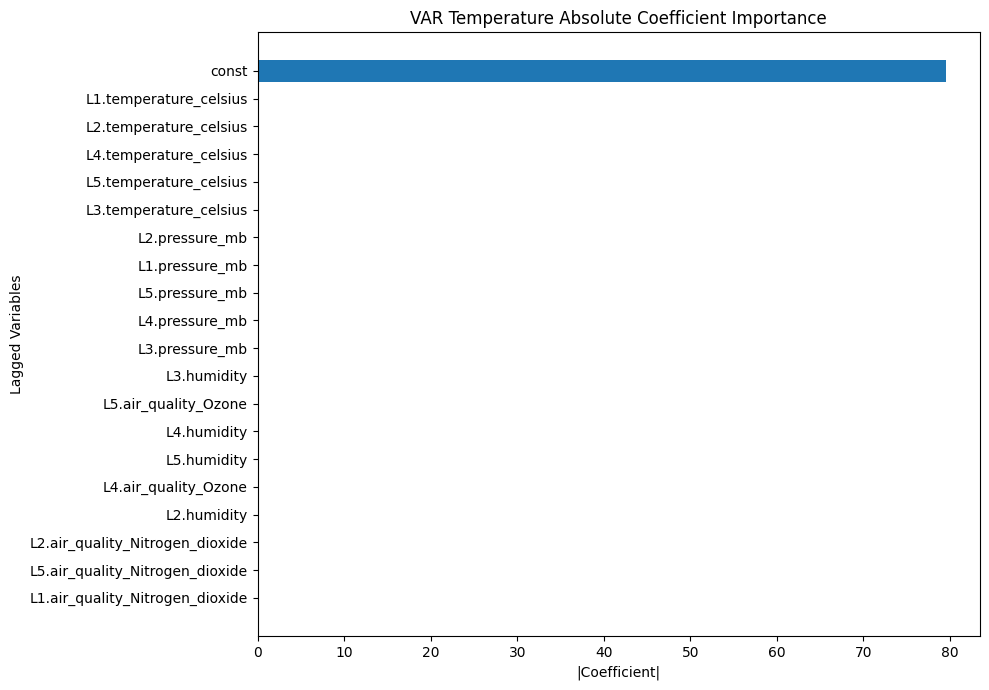

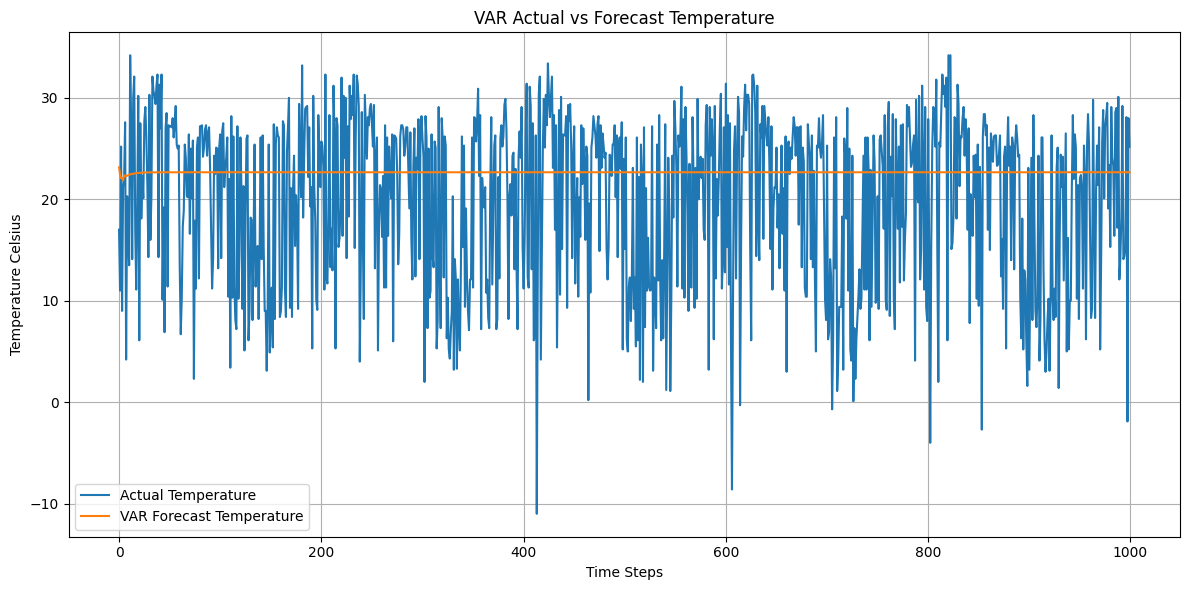

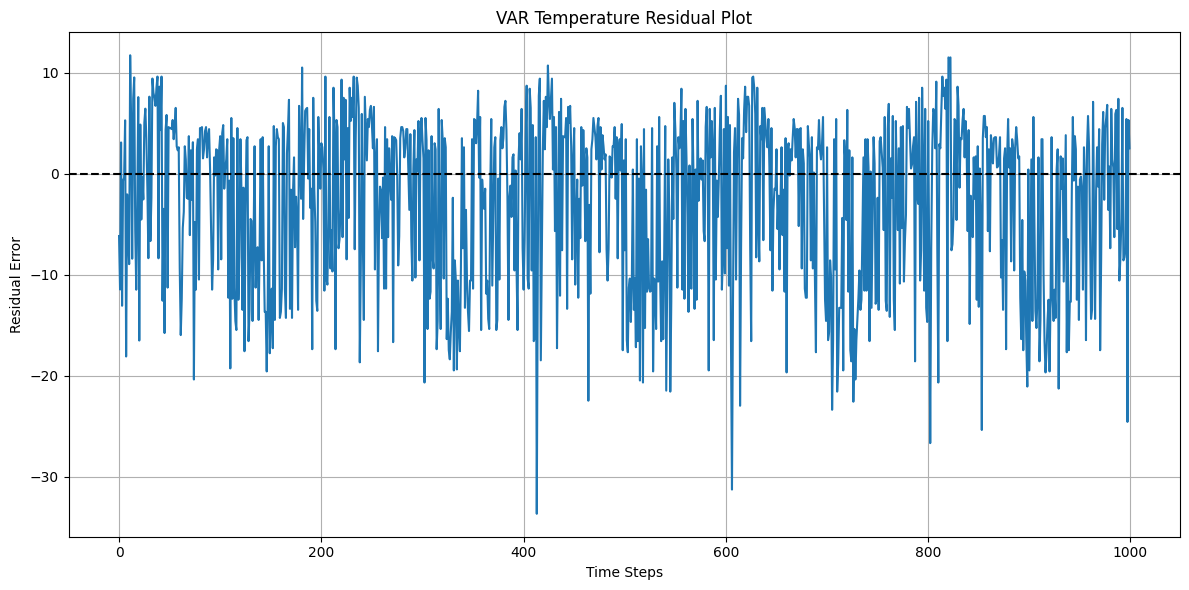

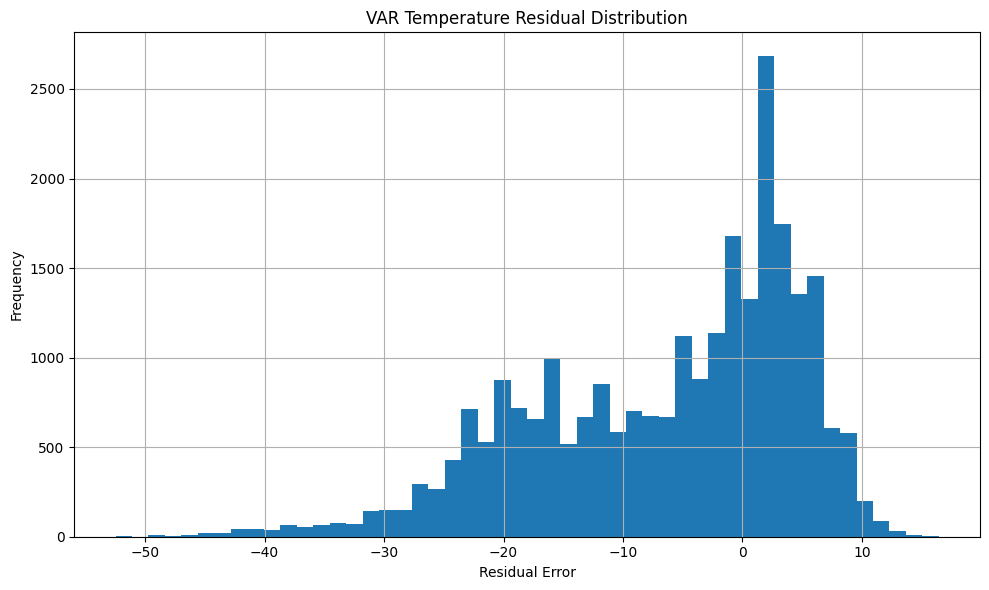

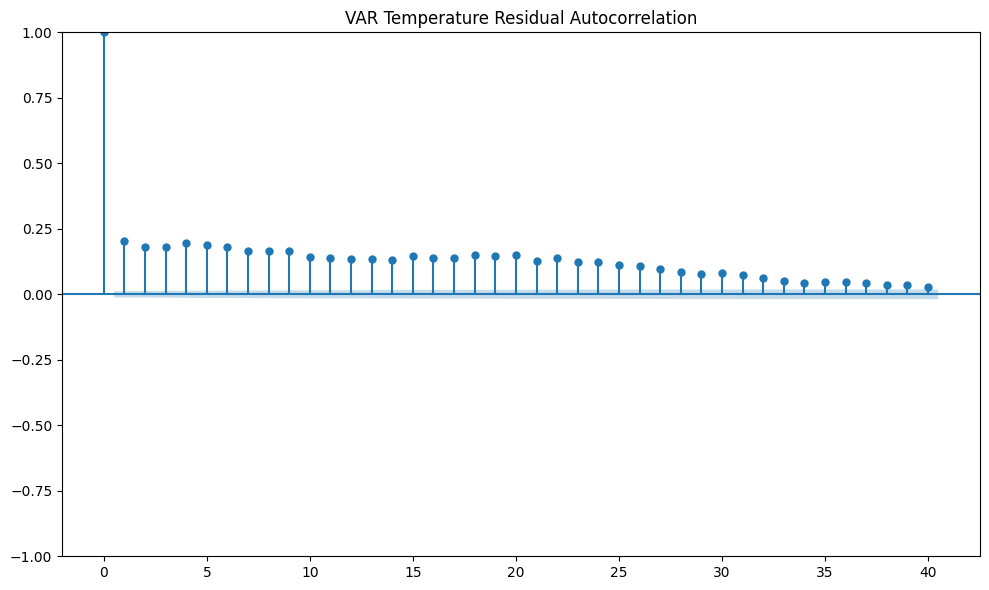

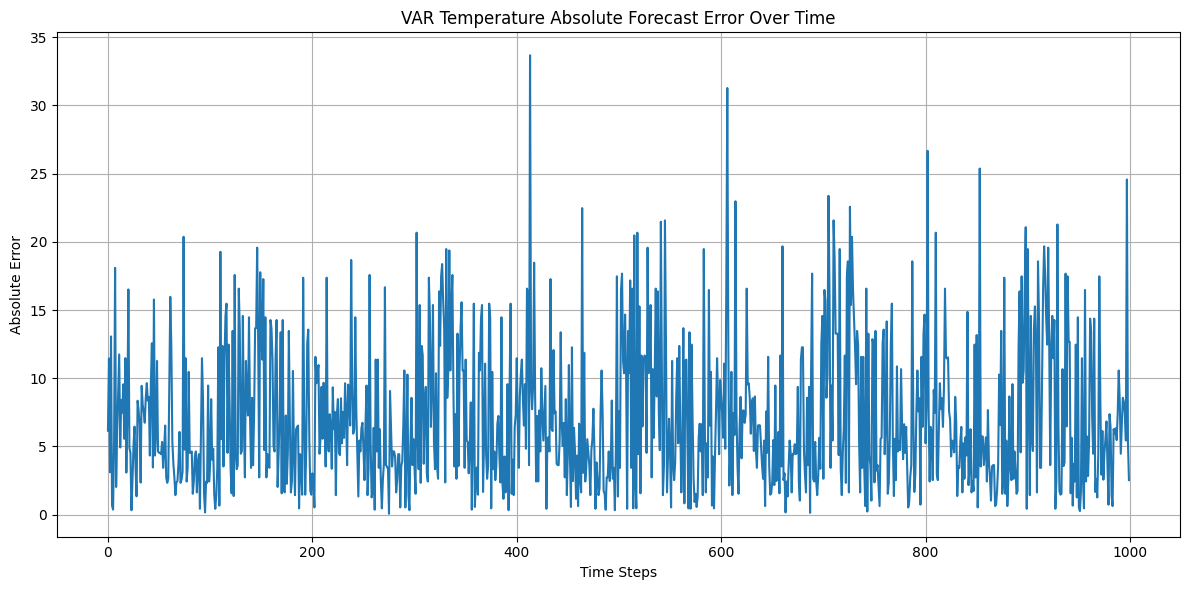

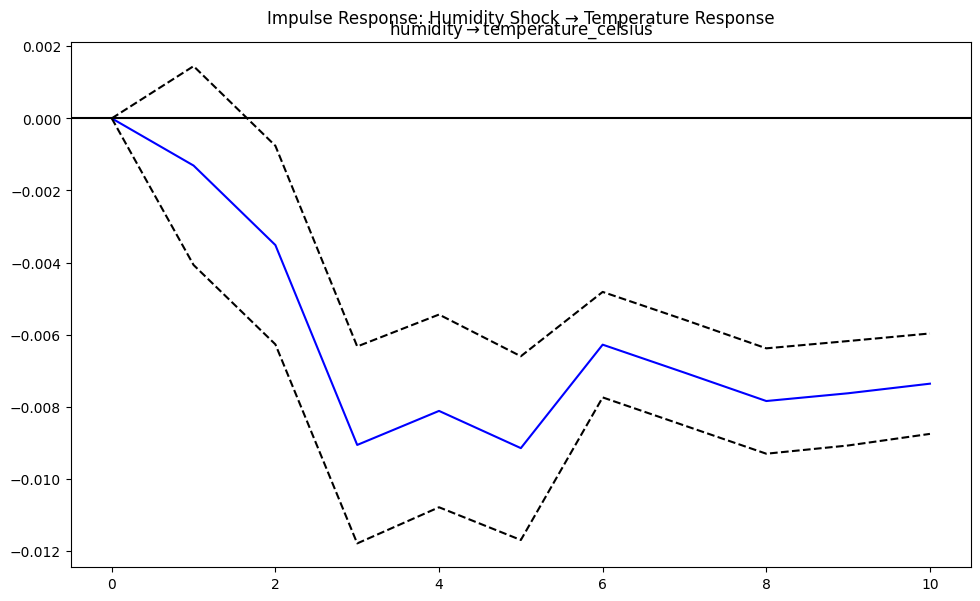

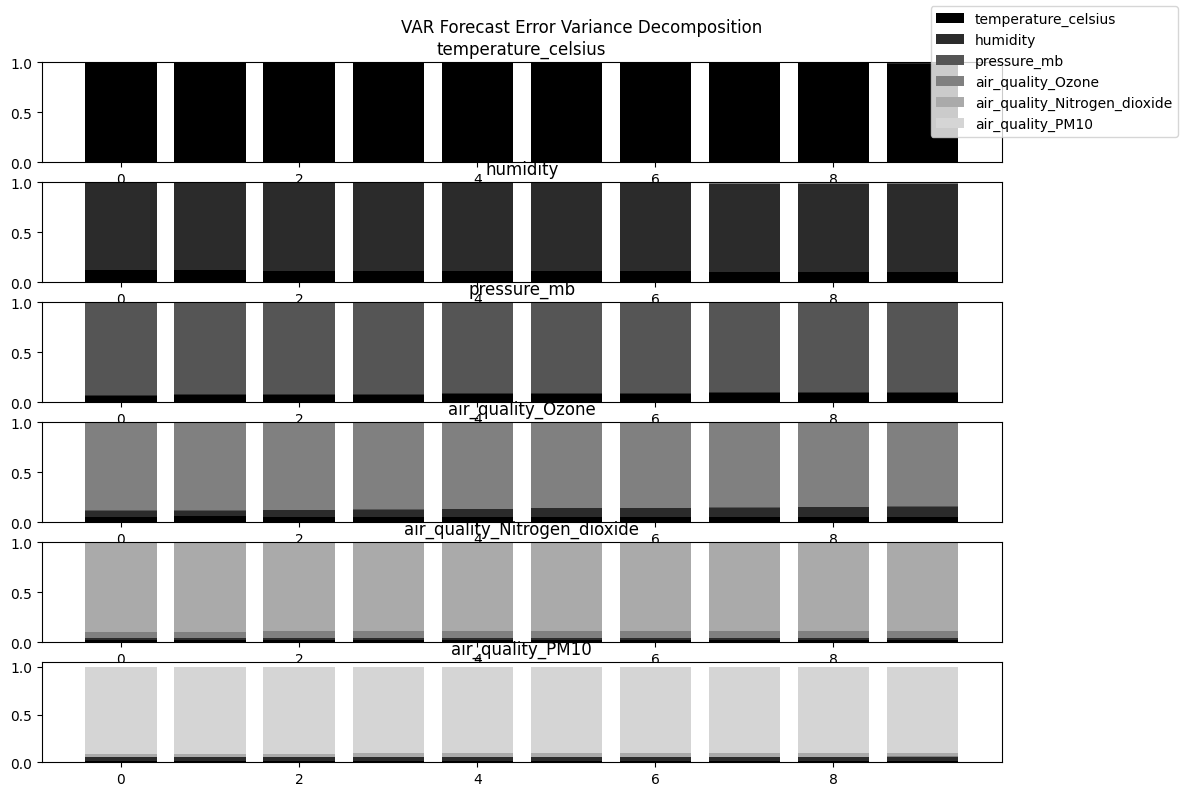

,Causing Variable,Caused Variable,Test Statistic,P-value,Conclusion
0,humidity,temperature_celsius,27.745216,3.362288e-28,Significant
1,pressure_mb,temperature_celsius,39.965002,3.144776e-41,Significant
2,air_quality_Ozone,temperature_celsius,10.711246,2.588122e-10,Significant
3,air_quality_Nitrogen_dioxide,temperature_celsius,2.093011,6.308226e-02,Not Significant
4,air_quality_PM10,temperature_celsius,63.016766,5.942228e-66,Significant


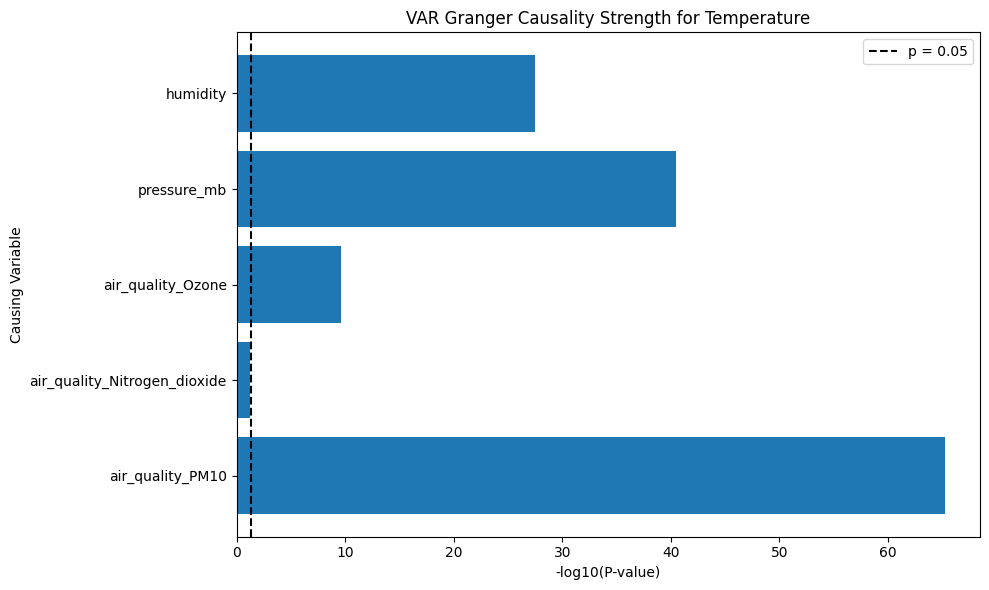

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
# ============================================================
# TEMPERATURE VAR EXPLAINABILITY + DOWNLOAD ALL CHARTS
# ============================================================

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

save_dir = "/content/Temperature_VAR_XAI_Outputs"
os.makedirs(save_dir, exist_ok=True)

target = "temperature_celsius"

var_features = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_PM10"
]

# ============================================================
# 1. FIT VAR MODEL
# ============================================================

train_var = train_df[var_features].dropna()
test_var = test_df[var_features].dropna()

var_model = VAR(train_var)
var_fit = var_model.fit(maxlags=5)

print(var_fit.summary())

# ============================================================
# 2. FORECAST TEMPERATURE
# ============================================================

lag_order = var_fit.k_ar

forecast = var_fit.forecast(
    train_var.values[-lag_order:],
    steps=len(test_var)
)

forecast_df = pd.DataFrame(
    forecast,
    index=test_var.index,
    columns=var_features
)

y_true = test_var[target].reset_index(drop=True)
y_pred = forecast_df[target].reset_index(drop=True)

residuals = y_true - y_pred
absolute_error = np.abs(residuals)

# ============================================================
# 3. SAVE METRICS
# ============================================================

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

y_true_safe = np.where(np.array(y_true) == 0, 1e-10, y_true)
accuracy = 100 - (np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100)

metrics_df = pd.DataFrame({
    "Model": ["VAR"],
    "Target": ["temperature_celsius"],
    "MSE": [mse],
    "RMSE": [rmse],
    "MAE": [mae],
    "R2": [r2],
    "Accuracy (%)": [accuracy]
})

metrics_df.to_csv(f"{save_dir}/Temperature_VAR_Metrics.csv", index=False)
display(metrics_df)

# ============================================================
# 4. FULL COEFFICIENT TABLE
# ============================================================

var_coef_table = var_fit.params

var_coef_table.to_csv(
    f"{save_dir}/VAR_Temperature_Full_Coefficient_Table.csv"
)

display(var_coef_table)

# ============================================================
# 5. TEMPERATURE EQUATION COEFFICIENTS
# ============================================================

temperature_coef = var_coef_table[target].sort_values(
    key=lambda x: np.abs(x),
    ascending=False
)

temperature_coef_df = pd.DataFrame({
    "Variable": temperature_coef.index,
    "Coefficient": temperature_coef.values,
    "Absolute_Coefficient": np.abs(temperature_coef.values)
})

temperature_coef_df.to_csv(
    f"{save_dir}/VAR_Temperature_Equation_Coefficients.csv",
    index=False
)

display(temperature_coef_df)

# ============================================================
# 6. COEFFICIENT BAR PLOT
# ============================================================

top_coef = temperature_coef_df.head(20)

plt.figure(figsize=(10,7))

plt.barh(
    top_coef["Variable"][::-1],
    top_coef["Coefficient"][::-1]
)

plt.axvline(0, color="black", linewidth=1)
plt.title("VAR Temperature Equation Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Lagged Variables")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/01_VAR_Temperature_Coefficient_Bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 7. ABSOLUTE COEFFICIENT IMPORTANCE
# ============================================================

plt.figure(figsize=(10,7))

plt.barh(
    top_coef["Variable"][::-1],
    top_coef["Absolute_Coefficient"][::-1]
)

plt.title("VAR Temperature Absolute Coefficient Importance")
plt.xlabel("|Coefficient|")
plt.ylabel("Lagged Variables")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/02_VAR_Temperature_Absolute_Coefficient_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 8. ACTUAL VS FORECAST
# ============================================================

plot_n = min(1000, len(y_true))

plt.figure(figsize=(12,6))

plt.plot(y_true[:plot_n], label="Actual Temperature")
plt.plot(y_pred[:plot_n], label="VAR Forecast Temperature")

plt.title("VAR Actual vs Forecast Temperature")
plt.xlabel("Time Steps")
plt.ylabel("Temperature Celsius")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/03_VAR_Actual_vs_Forecast_Temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 9. RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(residuals[:plot_n])
plt.axhline(0, color="black", linestyle="--")

plt.title("VAR Temperature Residual Plot")
plt.xlabel("Time Steps")
plt.ylabel("Residual Error")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/04_VAR_Temperature_Residual_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 10. RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(residuals.dropna(), bins=50)

plt.title("VAR Temperature Residual Distribution")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/05_VAR_Temperature_Residual_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 11. RESIDUAL ACF
# ============================================================

fig, ax = plt.subplots(figsize=(10,6))

plot_acf(residuals.dropna(), lags=40, ax=ax)

plt.title("VAR Temperature Residual Autocorrelation")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/06_VAR_Temperature_Residual_ACF.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 12. ERROR OVER TIME
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(absolute_error[:plot_n])

plt.title("VAR Temperature Absolute Forecast Error Over Time")
plt.xlabel("Time Steps")
plt.ylabel("Absolute Error")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/07_VAR_Temperature_Error_Over_Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 13. IMPULSE RESPONSE FUNCTION
# ============================================================

irf = var_fit.irf(10)

fig = irf.plot(
    impulse="humidity",
    response="temperature_celsius"
)

fig.set_size_inches(10,6)

plt.suptitle("Impulse Response: Humidity Shock → Temperature Response")

plt.savefig(
    f"{save_dir}/08_VAR_IRF_Humidity_to_Temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 14. FORECAST ERROR VARIANCE DECOMPOSITION
# ============================================================

fevd = var_fit.fevd(10)

fig = fevd.plot()
fig.set_size_inches(12,8)

plt.suptitle("VAR Forecast Error Variance Decomposition")

plt.savefig(
    f"{save_dir}/09_VAR_FEVD_Temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 15. GRANGER CAUSALITY FOR TEMPERATURE
# ============================================================

granger_results = []

for feature in var_features:
    if feature != target:
        try:
            test_result = var_fit.test_causality(
                caused=target,
                causing=[feature],
                kind="f"
            )

            granger_results.append({
                "Causing Variable": feature,
                "Caused Variable": target,
                "Test Statistic": test_result.test_statistic,
                "P-value": test_result.pvalue,
                "Conclusion": "Significant" if test_result.pvalue < 0.05 else "Not Significant"
            })

        except Exception as e:
            granger_results.append({
                "Causing Variable": feature,
                "Caused Variable": target,
                "Test Statistic": np.nan,
                "P-value": np.nan,
                "Conclusion": str(e)
            })

granger_df = pd.DataFrame(granger_results)

granger_df.to_csv(
    f"{save_dir}/VAR_Granger_Causality_Temperature.csv",
    index=False
)

display(granger_df)

# ============================================================
# 16. GRANGER CAUSALITY PLOT
# ============================================================

granger_plot_df = granger_df.dropna().copy()

granger_plot_df["-log10(P-value)"] = -np.log10(
    granger_plot_df["P-value"]
)

plt.figure(figsize=(10,6))

plt.barh(
    granger_plot_df["Causing Variable"][::-1],
    granger_plot_df["-log10(P-value)"][::-1]
)

plt.axvline(
    -np.log10(0.05),
    color="black",
    linestyle="--",
    label="p = 0.05"
)

plt.title("VAR Granger Causality Strength for Temperature")
plt.xlabel("-log10(P-value)")
plt.ylabel("Causing Variable")
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{save_dir}/10_VAR_Granger_Causality_Temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 17. ZIP AND DOWNLOAD ALL OUTPUTS
# ============================================================

zip_path = "/content/Temperature_VAR_XAI_Outputs.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for root, dirs, files_list in os.walk(save_dir):
        for file in files_list:
            file_path = os.path.join(root, file)
            zipf.write(file_path, arcname=file)

files.download(zip_path)